# Rental Pricing Dataset, Malaysia

Dataset Link: https://www.kaggle.com/datasets/ariewijaya/rent-pricing-kuala-lumpur-malaysi

In [2]:
!pip install pandas matplotlib numpy seaborn scikit-learn catboost xgboost

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
# Turn on or off code that takes long to run
train_MLP = True;
hyperparameter_tuning_RandomForest = True;
hyperparameter_tuning_XGBoost = True;
hyperparameter_tuning_CatBoost = True;

In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [6]:
df = pd.read_csv("mudah-apartment-kl-selangor.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ads_id                 19991 non-null  int64  
 1   prop_name              19043 non-null  str    
 2   completion_year        10806 non-null  float64
 3   monthly_rent           19989 non-null  str    
 4   location               19991 non-null  str    
 5   property_type          19991 non-null  str    
 6   rooms                  19985 non-null  str    
 7   parking                14289 non-null  float64
 8   bathroom               19985 non-null  float64
 9   size                   19991 non-null  str    
 10  furnished              19986 non-null  str    
 11  facilities             17782 non-null  str    
 12  additional_facilities  14043 non-null  str    
 13  region                 19991 non-null  str    
dtypes: float64(3), int64(1), str(10)
memory usage: 2.1 MB


In [7]:
df.head(2)

,ads_id,prop_name,completion_year,monthly_rent,location,property_type,rooms,parking,bathroom,size,furnished,facilities,additional_facilities,region
0,100323185,The Hipster @ Taman Desa,2022.0,RM 4 200 per month,Kuala Lumpur - Taman Desa,Condominium,5,2.0,6.0,1842 sq.ft.,Fully Furnished,"Minimart, Gymnasium, Security, Playground, Swimming Pool, Parking, Lift, Barbeque area, Multipurpose hall, Jogging Track","Air-Cond, Cooking Allowed, Washing Machine",Kuala Lumpur
1,100203973,Segar Courts,NaN,RM 2 300 per month,Kuala Lumpur - Cheras,Condominium,3,1.0,2.0,1170 sq.ft.,Partially Furnished,"Playground, Parking, Barbeque area, Security, Jogging Track, Swimming Pool, Gymnasium, Lift, Sauna","Air-Cond, Cooking Allowed, Near KTM/LRT",Kuala Lumpur


## Data Cleaning

In [8]:
df = df.drop(["ads_id"], axis=1)

In [9]:
# Strip text from the rental price
df['monthly_rent'] = (
    df['monthly_rent']
    .str.replace('RM', '', regex=False)
    .str.replace('per month', '', regex=False)
    .str.replace(' ', '', regex=False)
)

df['monthly_rent'] = pd.to_numeric(df['monthly_rent'], errors='coerce')

In [10]:
# Fill missing parking counts with 1 if facilities mention parking
mask = (
    df['parking'].isna() &
    df['facilities'].str.lower().str.contains('parking', na=False)
)

df.loc[mask, 'parking'] = 1
print(f'Total rows filled with 1 for parking field {mask.sum()}')
print(f'Parking with NULL Values {df['parking'].isna().sum()}')

Total rows filled with 1 for parking field 3754
Parking with NULL Values 1948


In [11]:
# Drop the 'Kuala Lumput -' from the location field
df['location'] = df['location'].str.replace(r'^(Kuala Lumpur|Selangor)\s*-\s*', '', regex=True)
print(df['location'].nunique())

129


In [12]:
# Drop the sq.ft. from size
df["size"] = df["size"].str.extract(r"(\d+)").astype(int)

In [13]:
# Encode furnished into one-hot encodings
df["fully_furnished"] = (
    df["furnished"]
    .str.strip()
    .str.lower()
    .eq("fully furnished")
    .astype(int)
)
df = df.drop(columns=["furnished"])

In [14]:
# Convert year information into age
# 2023 is used as the dataset was scrapped in that year
current_year = 2023
df["property_age"] = current_year - df["completion_year"]
df = df.drop(columns=["completion_year"])

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19991 entries, 0 to 19990
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   prop_name              19043 non-null  str    
 1   monthly_rent           19989 non-null  float64
 2   location               19991 non-null  str    
 3   property_type          19991 non-null  str    
 4   rooms                  19985 non-null  str    
 5   parking                18043 non-null  float64
 6   bathroom               19985 non-null  float64
 7   size                   19991 non-null  int64  
 8   facilities             17782 non-null  str    
 9   additional_facilities  14043 non-null  str    
 10  region                 19991 non-null  str    
 11  fully_furnished        19991 non-null  int64  
 12  property_age           10806 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 2.0 MB


In [16]:
# Convert facilities data into one hot encodings
facilities_one_hot = df["facilities"].str.get_dummies(sep=", ")

# FIX: Removed axis=1 since columns=[...] is explicitly defined
facilities_one_hot = facilities_one_hot.drop(columns=["10", "11", "6"])

additional_facilities_one_hot = df["additional_facilities"].str.get_dummies(sep=", ")

df = df.join(facilities_one_hot)
df = df.join(additional_facilities_one_hot)

# FIX: Removed axis=1 since columns=[...] is explicitly defined
df = df.drop(columns=["facilities", "additional_facilities"])

In [17]:
# Remove anomalies of rental greater than RM18500 per month
num_removed = (df['monthly_rent'] > 18500).sum()
print(f"Rows to remove: {num_removed}")
df = df[df['monthly_rent'] <= 18500]

# Remove anomalies of rental less than RM300 per month
num_removed = (df['monthly_rent'] < 300).sum()
print(f"Rows to remove: {num_removed}")
df = df[df['monthly_rent'] >= 300]

Rows to remove: 35
Rows to remove: 51


In [18]:
df[['parking', 'rooms', 'bathroom']] = df[['parking', 'rooms' , 'bathroom']].fillna(0)

In [19]:
df['age_missing'] = df['property_age'].isna().astype(int)

df['property_age'] = df['property_age'].fillna(
    df['property_age'].median()
)

In [20]:
# Group Rare Categories of houses
# print(df['location'].unique())
# print(df['property_type'].unique())
# df['property_type'].value_counts()

rare_types = [
    'Others',
    'Duplex',
    'Townhouse Condo',
    'Houses'
]

df['property_type'] = df['property_type'].replace(
    rare_types,
    'Other'
)

In [21]:
null_row_count = df.isna().any(axis=1).sum()

print(f"Rows with nulls: {null_row_count}")

Rows with nulls: 936


In [22]:
# Convert rooms to numerical numbers and removing abnormal data with strong
df = df[df['rooms'] != 'More than 10']
df['rooms'] = pd.to_numeric(df['rooms'])

In [23]:
df.isna().sum().sort_values(ascending=False)

prop_name            935
monthly_rent           0
location               0
property_type          0
rooms                  0
parking                0
bathroom               0
size                   0
region                 0
fully_furnished        0
property_age           0
Barbeque area          0
Club house             0
Gymnasium              0
Jogging Track          0
Lift                   0
Minimart               0
Multipurpose hall      0
Parking                0
Playground             0
Sauna                  0
Security               0
Squash Court           0
Swimming Pool          0
Tennis Court           0
Air-Cond               0
Cooking Allowed        0
Internet               0
Near KTM/LRT           0
Washing Machine        0
age_missing            0
dtype: int64

## Exploratory Data Analysis

C:\Users\Sheng Xiang\AppData\Local\Temp\ipykernel_18688\4044126601.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1,2].set_xticklabels(


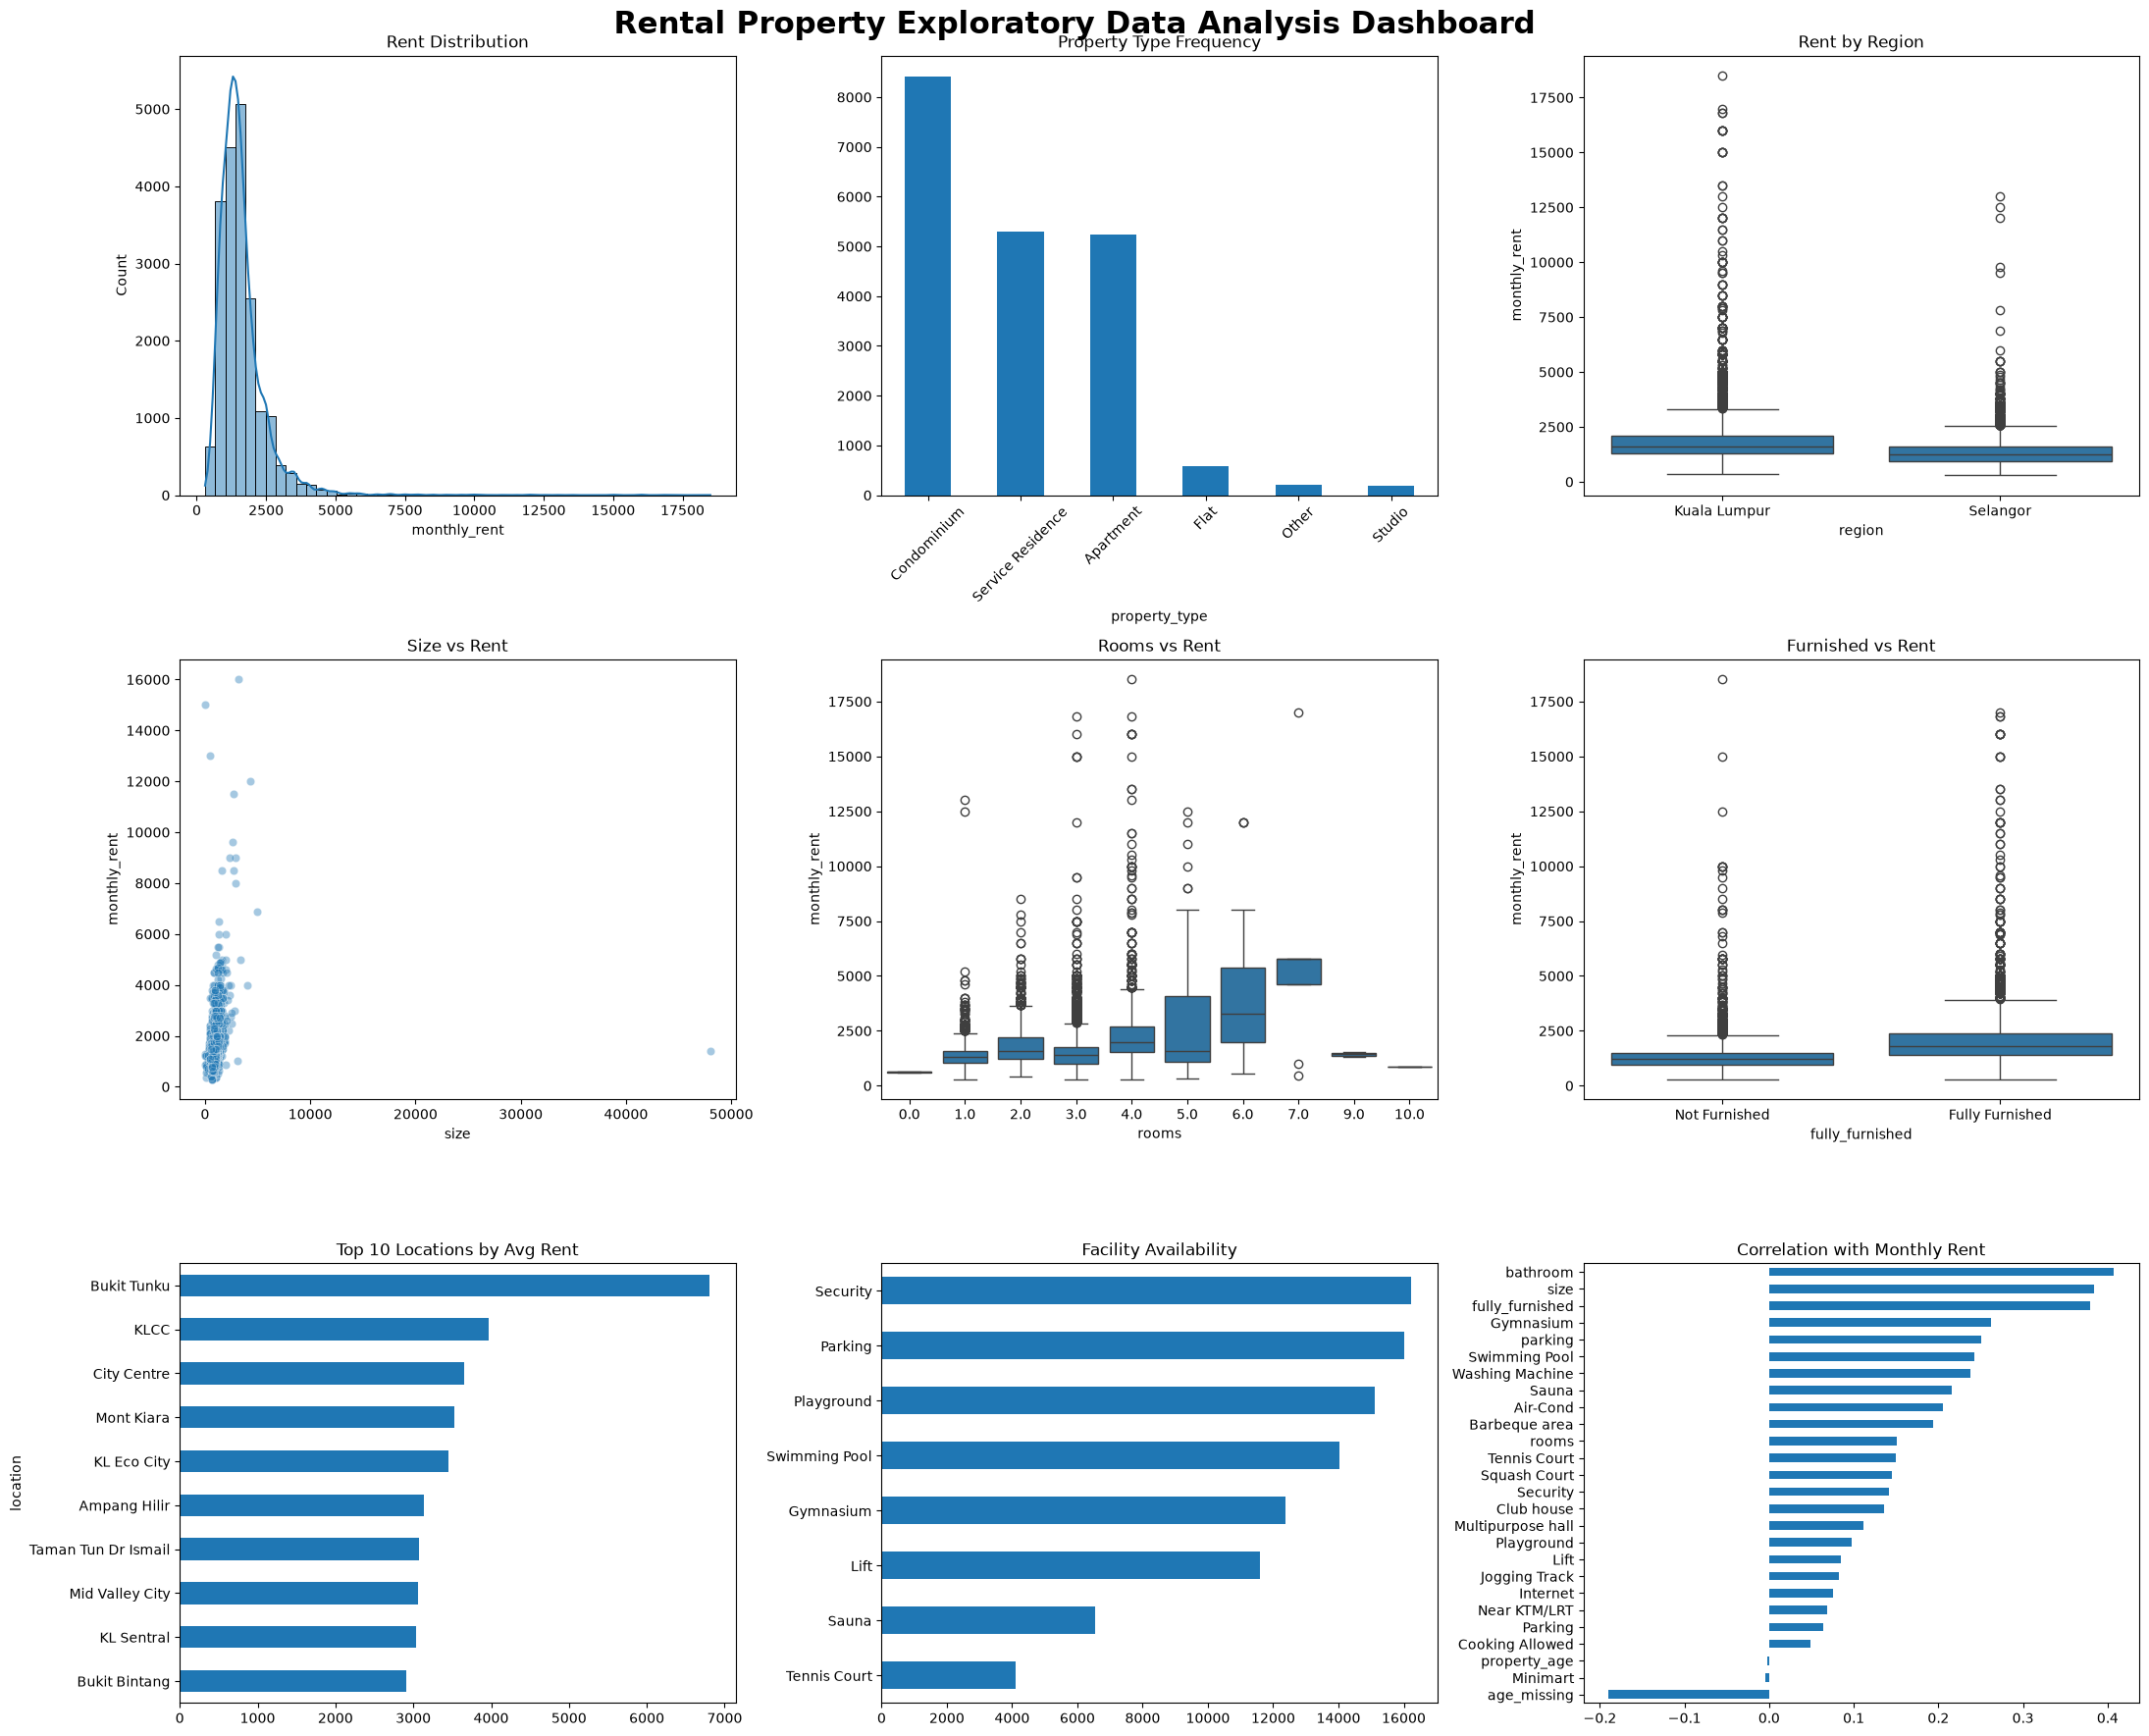

In [24]:
# Region column
# df['region'] = np.where(
#     df['region_Kuala Lumpur']==1,
#     'Kuala Lumpur',
#     'Selangor'
# )

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle('Rental Property Exploratory Data Analysis Dashboard',
             fontsize=22,
             fontweight='bold')

# -------------------------------------------------
# 1. Rent Distribution
# -------------------------------------------------
sns.histplot(df['monthly_rent'],
             bins=50,
             kde=True,
             ax=axes[0,0])

axes[0,0].set_title('Rent Distribution')

# -------------------------------------------------
# 2. Property Type Count
# -------------------------------------------------
df['property_type'].value_counts().plot(
    kind='bar',
    ax=axes[0,1]
)

axes[0,1].set_title('Property Type Frequency')
axes[0,1].tick_params(axis='x', rotation=45)

# -------------------------------------------------
# 3. Region Comparison
# -------------------------------------------------
sns.boxplot(
    data=df,
    x='region',
    y='monthly_rent',
    ax=axes[0,2]
)

axes[0,2].set_title('Rent by Region')

# -------------------------------------------------
# 4. Size vs Rent
# -------------------------------------------------
sns.scatterplot(
    data=df.sample(min(3000, len(df))),
    x='size',
    y='monthly_rent',
    alpha=0.4,
    ax=axes[1,0]
)

axes[1,0].set_title('Size vs Rent')

# -------------------------------------------------
# 5. Rooms vs Rent
# -------------------------------------------------
sns.boxplot(
    data=df,
    x='rooms',
    y='monthly_rent',
    ax=axes[1,1]
)

axes[1,1].set_title('Rooms vs Rent')

# -------------------------------------------------
# 6. Furnished vs Rent
# -------------------------------------------------
sns.boxplot(
    data=df,
    x='fully_furnished',
    y='monthly_rent',
    ax=axes[1,2]
)

axes[1,2].set_title('Furnished vs Rent')
axes[1,2].set_xticklabels(
    ['Not Furnished','Fully Furnished']
)

# -------------------------------------------------
# 7. Top Locations
# -------------------------------------------------
top_loc = (
    df.groupby('location')['monthly_rent']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_loc.sort_values().plot(
    kind='barh',
    ax=axes[2,0]
)

axes[2,0].set_title('Top 10 Locations by Avg Rent')

# -------------------------------------------------
# 8. Common Facilities
# -------------------------------------------------
facilities = [
    'Swimming Pool',
    'Gymnasium',
    'Security',
    'Parking',
    'Playground',
    'Lift',
    'Sauna',
    'Tennis Court'
]

df[facilities].sum().sort_values().plot(
    kind='barh',
    ax=axes[2,1]
)

axes[2,1].set_title('Facility Availability')

# -------------------------------------------------
# 9. Correlation with Rent
# -------------------------------------------------
corr = (
    df.select_dtypes(include=['int64','float64'])
      .corr()['monthly_rent']
      .sort_values()
)

corr.drop('monthly_rent').plot(
    kind='barh',
    ax=axes[2,2]
)

axes[2,2].set_title('Correlation with Monthly Rent')

plt.tight_layout()
plt.show()

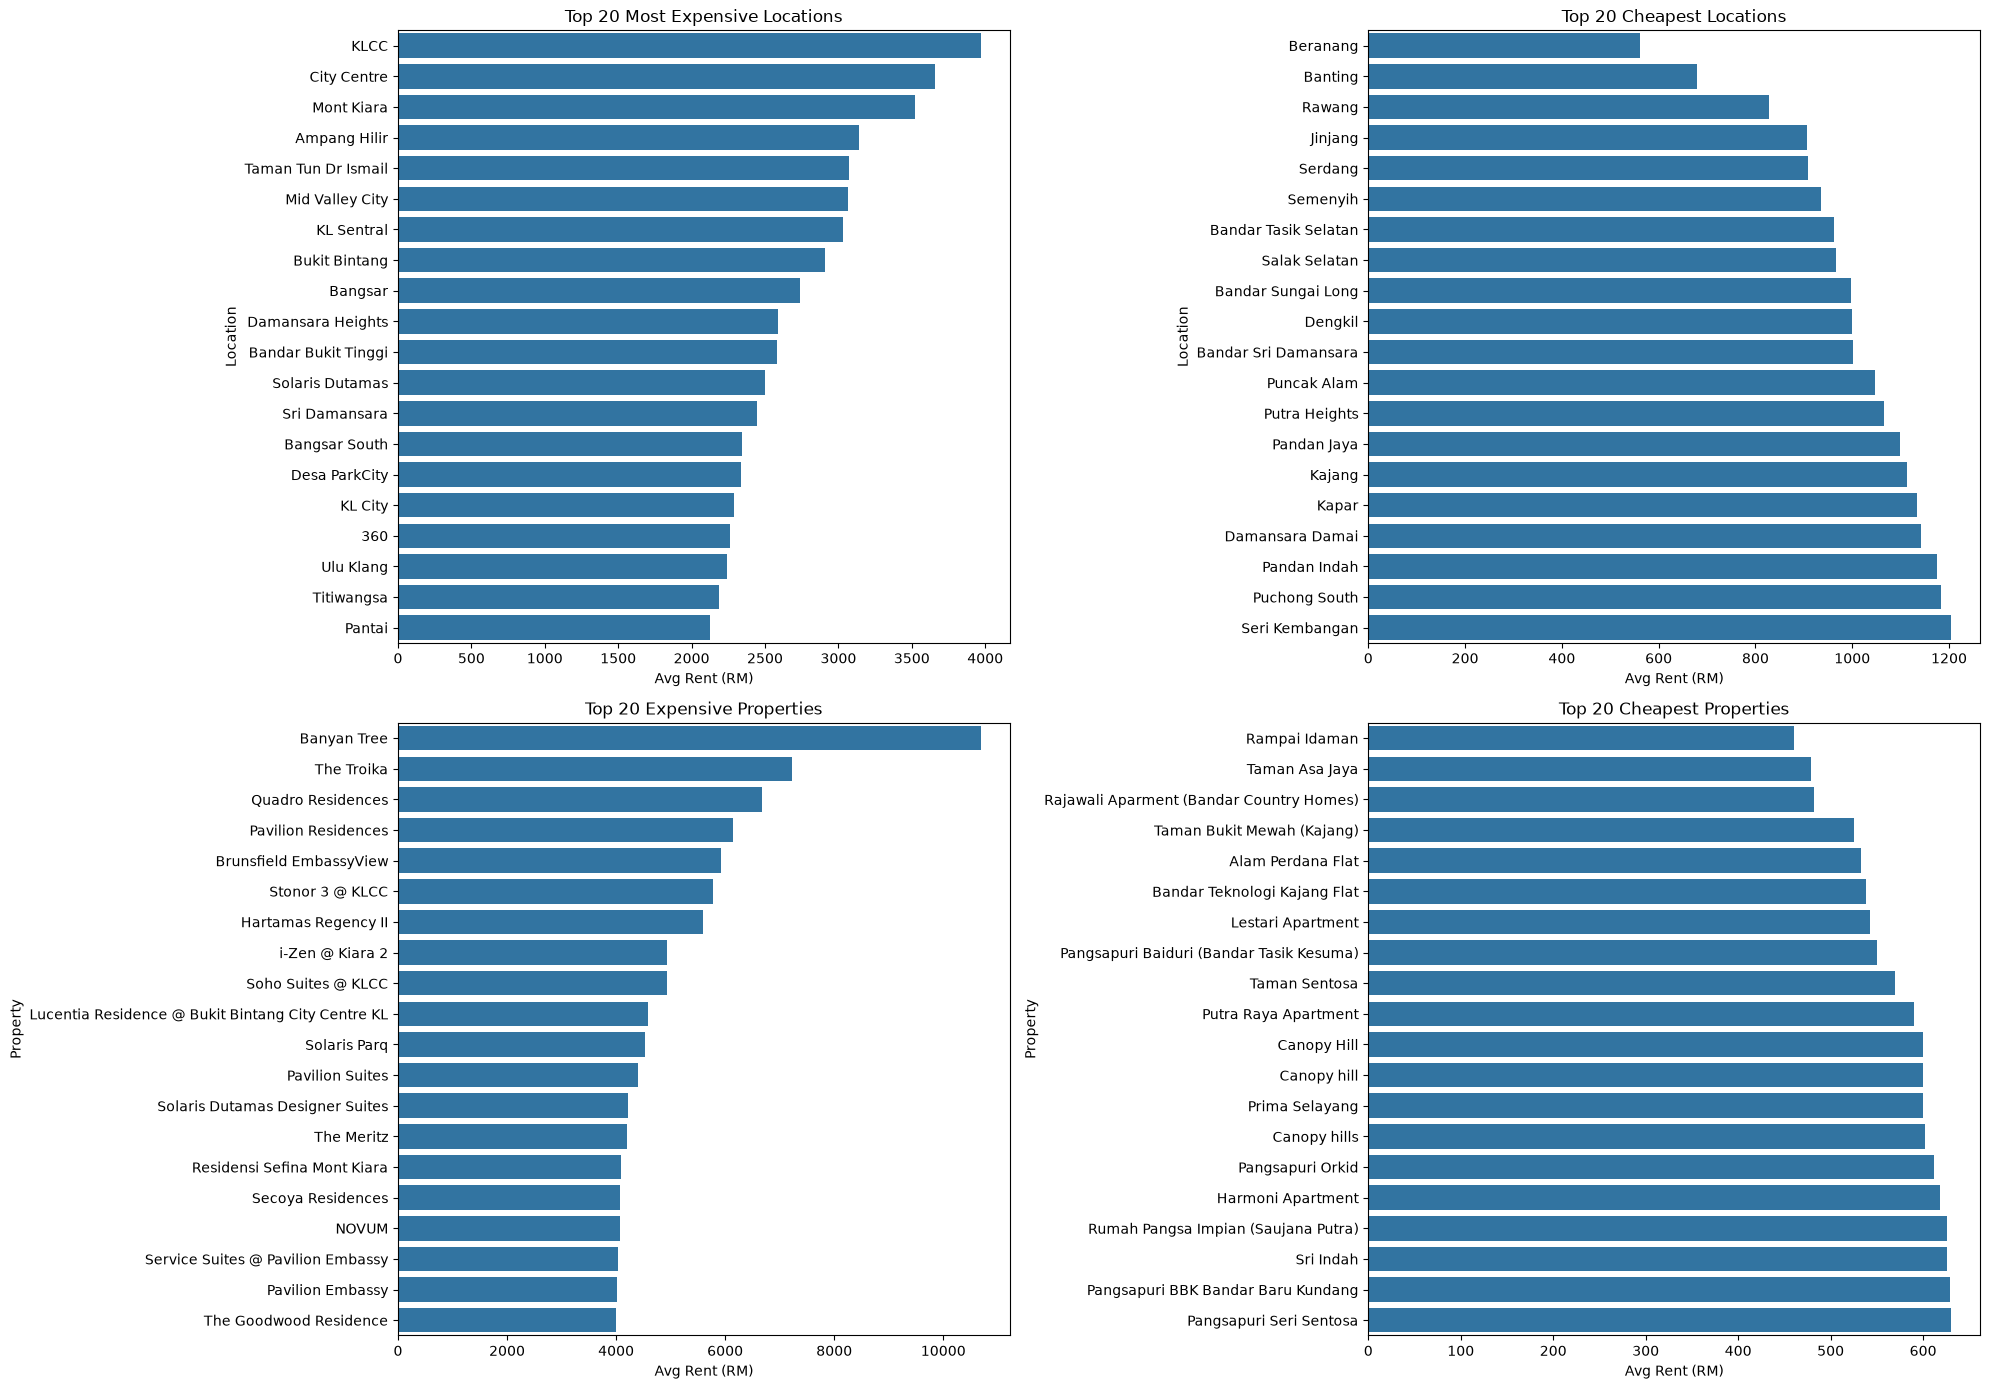

In [25]:
location_stats = (
    df.groupby('location')['monthly_rent']
      .agg(['count', 'mean'])
      .query('count >= 5')
)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# -------------------------
# 1. Top expensive locations
# -------------------------
top_loc = location_stats.sort_values('mean', ascending=False).head(20)

sns.barplot(
    data=top_loc.reset_index(),
    x='mean',
    y='location',
    ax=axes[0,0]
)
axes[0,0].set_title('Top 20 Most Expensive Locations')
axes[0,0].set_xlabel('Avg Rent (RM)')
axes[0,0].set_ylabel('Location')

# -------------------------
# 2. Cheapest locations
# -------------------------
bottom_loc = location_stats.sort_values('mean', ascending=True).head(20)

sns.barplot(
    data=bottom_loc.reset_index(),
    x='mean',
    y='location',
    ax=axes[0,1]
)
axes[0,1].set_title('Top 20 Cheapest Locations')
axes[0,1].set_xlabel('Avg Rent (RM)')
axes[0,1].set_ylabel('Location')

# -------------------------
# 3. Expensive properties
# -------------------------
top_prop = (
    df.groupby('prop_name')['monthly_rent']
      .agg(['count', 'mean'])
      .query('count >= 5')
      .sort_values('mean', ascending=False)
      .head(20)
)

sns.barplot(
    data=top_prop.reset_index(),
    x='mean',
    y='prop_name',
    ax=axes[1,0]
)
axes[1,0].set_title('Top 20 Expensive Properties')
axes[1,0].set_xlabel('Avg Rent (RM)')
axes[1,0].set_ylabel('Property')

# -------------------------
# 4. Cheapest properties
# -------------------------
bottom_prop = (
    df.groupby('prop_name')['monthly_rent']
      .agg(['count', 'mean'])
      .query('count >= 5')
      .sort_values('mean', ascending=True)
      .head(20)
)

sns.barplot(
    data=bottom_prop.reset_index(),
    x='mean',
    y='prop_name',
    ax=axes[1,1]
)
axes[1,1].set_title('Top 20 Cheapest Properties')
axes[1,1].set_xlabel('Avg Rent (RM)')
axes[1,1].set_ylabel('Property')

plt.tight_layout()
plt.show()

## Feature Selection and Data Encoding

In [26]:
# Remove property name from the dataframe
df_property_name = df.pop('prop_name').to_frame()

# Remoce duplicate Parking column
df = df.drop(columns=['Parking'])

In [27]:
# Group facilities columns together
df['basic_facilities'] = (
    df['Lift'] +
    df['Air-Cond'] +
    df['Washing Machine'] +
    df['Internet'] +
    df['Cooking Allowed']
)

df['building_facilities'] = (
    df['Gymnasium'] +
    df['Swimming Pool'] +
    df['Security'] +
    df['Playground'] +
    df['Jogging Track'] +
    df['Multipurpose hall']
)

df['luxury_facilities'] = (
    df['Squash Court'] +
    df['Tennis Court'] +
    df['Sauna'] +
    df['Club house'] +
    df['Barbeque area']
)

facility_cols = [
    'Barbeque area', 'Club house', 'Gymnasium', 'Jogging Track',
    'Lift', 'Minimart', 'Multipurpose hall',
    'Playground', 'Sauna', 'Security', 'Squash Court',
    'Swimming Pool', 'Tennis Court', 'Air-Cond',
    'Cooking Allowed', 'Internet', 'Near KTM/LRT', 'Washing Machine'
]

df = df.drop(columns=facility_cols)


In [28]:
# Helper function for one_hot_encoding 
def one_hot_encode (df_in):
    _df = df_in.copy()
    _df = pd.get_dummies(_df, columns=['property_type'], drop_first=True)
    _df = pd.get_dummies(_df, columns=['location'], drop_first=True)
    _df = pd.get_dummies(_df, columns=["region"], dtype=int)
    return _df

In [29]:
df.head()

,monthly_rent,location,property_type,rooms,parking,bathroom,size,region,fully_furnished,property_age,age_missing,basic_facilities,building_facilities,luxury_facilities
0,4200.0,Taman Desa,Condominium,5.0,2.0,6.0,1842,Kuala Lumpur,1,1.0,0,4,6,1
1,2300.0,Cheras,Condominium,3.0,1.0,2.0,1170,Kuala Lumpur,0,6.0,1,3,5,2
2,1000.0,Taman Desa,Apartment,3.0,0.0,2.0,650,Kuala Lumpur,1,6.0,1,1,2,0
3,1700.0,Sentul,Apartment,2.0,1.0,2.0,743,Kuala Lumpur,0,3.0,0,3,4,1
4,1299.0,Mont Kiara,Service Residence,1.0,1.0,1.0,494,Kuala Lumpur,0,6.0,1,2,6,2


In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 19901 entries, 0 to 19990
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   monthly_rent         19901 non-null  float64
 1   location             19901 non-null  str    
 2   property_type        19901 non-null  str    
 3   rooms                19901 non-null  float64
 4   parking              19901 non-null  float64
 5   bathroom             19901 non-null  float64
 6   size                 19901 non-null  int64  
 7   region               19901 non-null  str    
 8   fully_furnished      19901 non-null  int64  
 9   property_age         19901 non-null  float64
 10  age_missing          19901 non-null  int64  
 11  basic_facilities     19901 non-null  int64  
 12  building_facilities  19901 non-null  int64  
 13  luxury_facilities    19901 non-null  int64  
dtypes: float64(5), int64(6), str(3)
memory usage: 2.3 MB
